In [1]:
# =====================
# DAY 6 - ADVANCED ANALYTICS
# Bluestock MF Analytics
# =====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style="whitegrid")
os.makedirs("../charts", exist_ok=True)

# Data load karo
nav_df = pd.read_csv("../data/processed/clean_nav.csv",
                     parse_dates=['date'])
nav_returns = pd.read_csv("../data/processed/returns_computed.csv",
                          parse_dates=['date'])
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")
txn_df = pd.read_csv("../data/processed/clean_transactions.csv",
                     parse_dates=['transaction_date'])
perf_df = pd.read_csv("../data/processed/clean_performance.csv")
holdings_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("✅ All data loaded!")
print(f"  NAV Returns  : {nav_returns.shape}")
print(f"  Transactions : {txn_df.shape}")
print(f"  Performance  : {perf_df.shape}")
print(f"  Holdings     : {holdings_df.shape}")

✅ All data loaded!
  NAV Returns  : (64280, 7)
  Transactions : (32778, 13)
  Performance  : (40, 19)
  Holdings     : (322, 8)


TASK 1 - VALUE AT RISK (VaR) & CONDITIONAL VaR

Top 10 Riskiest Funds (Highest VaR):
                                       scheme_name  var_95_pct  cvar_95_pct  worst_day_pct
            ABSL Small Cap Fund - Regular - Growth     -2.3915      -3.0289        -5.1847
            Axis Small Cap Fund - Regular - Growth     -2.3284      -2.9690        -4.8367
         SBI Small Cap Fund - Direct Plan - Growth     -2.3155      -3.0163        -4.5429
    Nippon India Small Cap Fund - Regular - Growth     -2.2810      -2.9940        -5.8102
             DSP Small Cap Fund - Regular - Growth     -2.1520      -2.8573        -4.8870
        SBI Small Cap Fund - Regular Plan - Growth     -2.1502      -2.8444        -4.5180
               Axis Midcap Fund - Regular - Growth     -1.6997      -2.2375        -4.0755
     Kotak Emerging Equity Fund - Regular - Growth     -1.6950      -2.1251        -4.0323
HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.6902      -2.1850        -4.4238
     

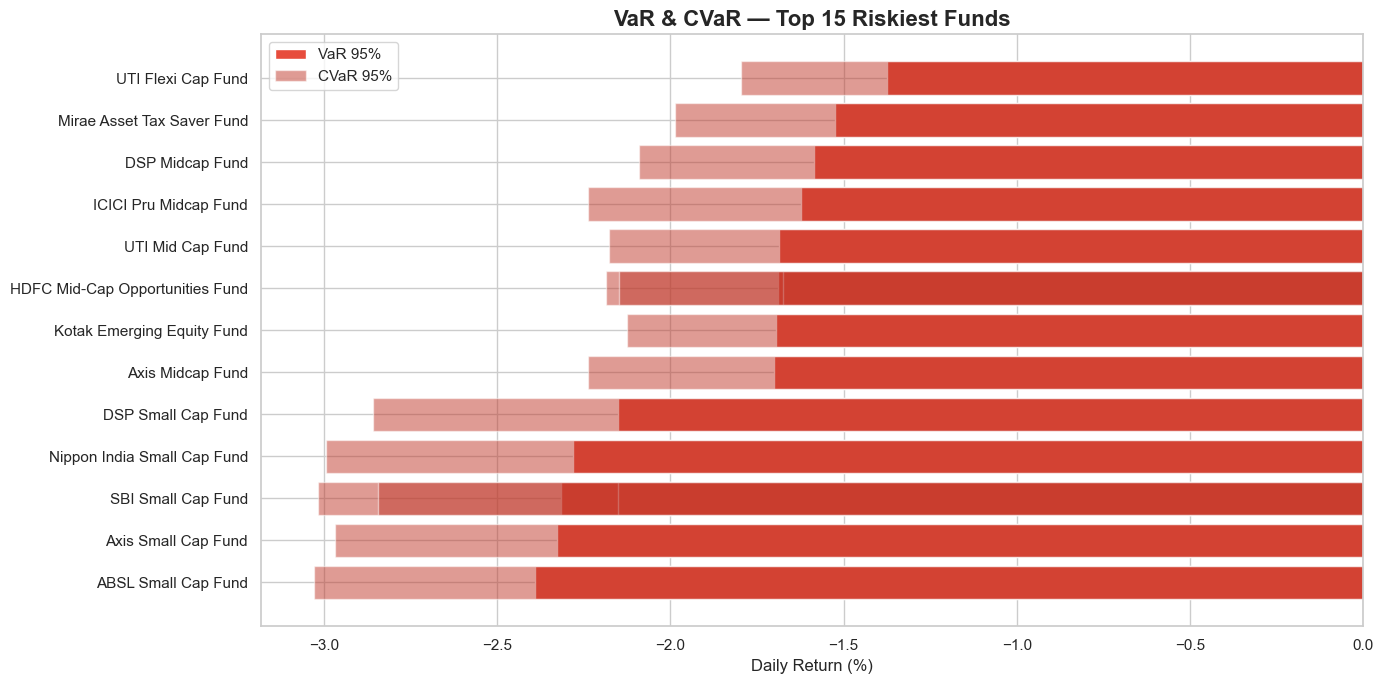


✅ Saved: var_cvar_report.csv + chart


In [2]:
# =====================
# TASK 1 - VaR & CVaR
# =====================

print("=" * 60)
print("TASK 1 - VALUE AT RISK (VaR) & CONDITIONAL VaR")
print("=" * 60)

var_results = []

for code, group in nav_returns.groupby('amfi_code'):
    returns = group['daily_return'].dropna()

    if len(returns) < 30:
        continue

    # VaR 95% = 5th percentile
    var_95 = np.percentile(returns, 5)

    # CVaR = mean of returns below VaR
    cvar_95 = returns[returns <= var_95].mean()

    var_results.append({
        'amfi_code': code,
        'var_95_pct': round(var_95 * 100, 4),
        'cvar_95_pct': round(cvar_95 * 100, 4),
        'worst_day_pct': round(returns.min() * 100, 4),
        'best_day_pct': round(returns.max() * 100, 4),
        'total_days': len(returns)
    })

var_df = pd.DataFrame(var_results)
var_df = var_df.merge(
    fund_df[['amfi_code', 'scheme_name',
             'sub_category', 'fund_house']],
    on='amfi_code', how='left')

print(f"\nTop 10 Riskiest Funds (Highest VaR):")
print(var_df.sort_values('var_95_pct').head(10)[
    ['scheme_name', 'var_95_pct',
     'cvar_95_pct', 'worst_day_pct']].to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(14, 7))
var_sorted = var_df.sort_values('var_95_pct').head(15)
ax.barh(
    var_sorted['scheme_name'].str.replace(
        ' - Direct Plan - Growth', '').str.replace(
        ' - Direct - Growth', '').str.replace(
        ' - Regular Plan - Growth', '').str.replace(
        ' - Regular - Growth', ''),
    var_sorted['var_95_pct'],
    color='#e74c3c', label='VaR 95%')
ax.barh(
    var_sorted['scheme_name'].str.replace(
        ' - Direct Plan - Growth', '').str.replace(
        ' - Direct - Growth', '').str.replace(
        ' - Regular Plan - Growth', '').str.replace(
        ' - Regular - Growth', ''),
    var_sorted['cvar_95_pct'],
    color='#c0392b', alpha=0.5, label='CVaR 95%')
ax.set_title('VaR & CVaR — Top 15 Riskiest Funds',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Daily Return (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/14_var_cvar.png', dpi=150)
plt.show()

var_df.to_csv("../data/processed/var_cvar_report.csv", index=False)
print("\n✅ Saved: var_cvar_report.csv + chart")

TASK 2 - ROLLING 90-DAY SHARPE RATIO


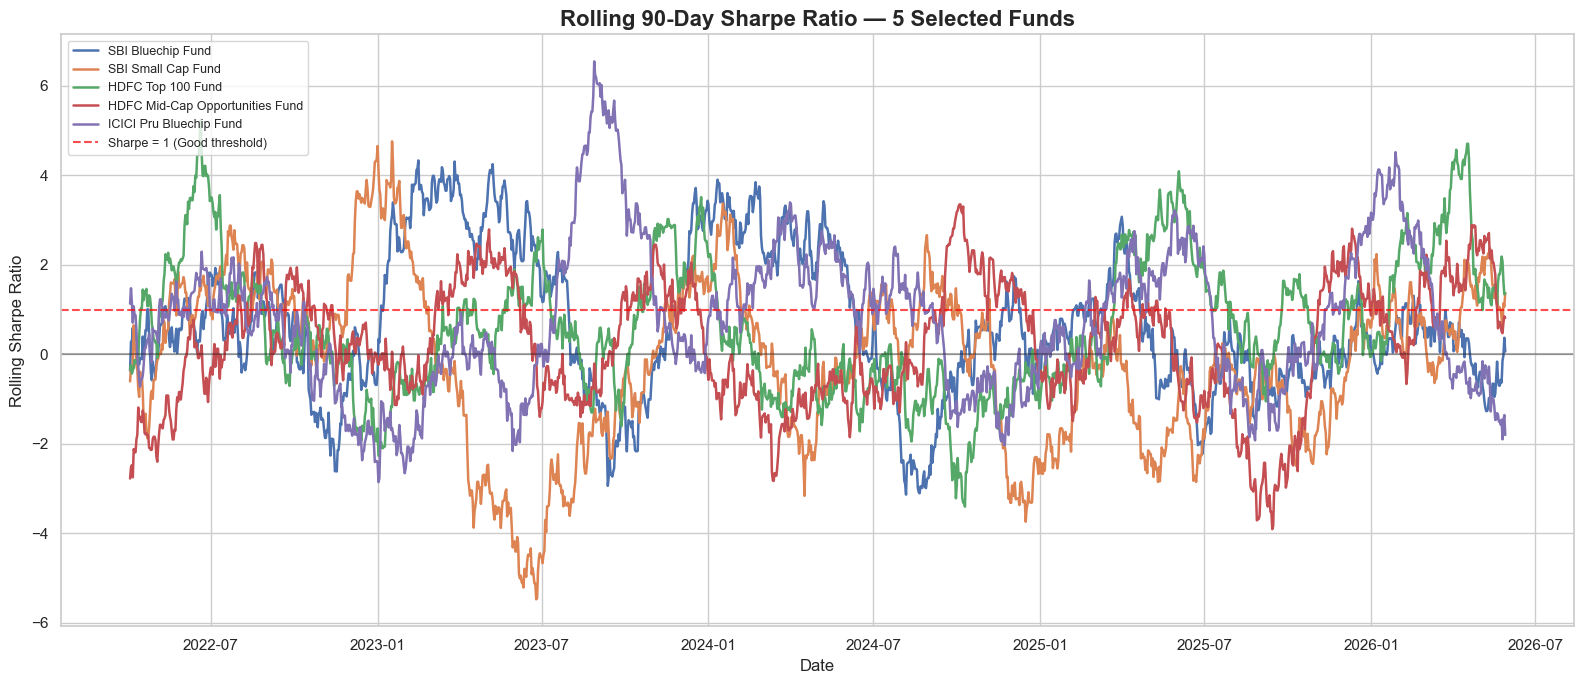

✅ Saved: rolling_sharpe_chart.png


In [3]:
# =====================
# TASK 2 - ROLLING SHARPE RATIO
# =====================

print("=" * 60)
print("TASK 2 - ROLLING 90-DAY SHARPE RATIO")
print("=" * 60)

RF_DAILY = 0.065 / 252

# 5 funds select karo
selected_funds = fund_df[
    fund_df['plan'] == 'Direct'
]['amfi_code'].head(5).tolist()

fig, ax = plt.subplots(figsize=(16, 7))

for code in selected_funds:
    group = nav_returns[
        nav_returns['amfi_code'] == code
    ].sort_values('date')

    if len(group) < 90:
        continue

    # Rolling Sharpe calculate karo
    rolling_mean = group['daily_return'].rolling(90).mean()
    rolling_std = group['daily_return'].rolling(90).std()
    rolling_sharpe = (rolling_mean - RF_DAILY) / rolling_std * np.sqrt(252)

    # Fund name nikalo
    name = fund_df[fund_df['amfi_code'] == code][
        'scheme_name'].values[0]
    name = name.replace(' - Direct Plan - Growth', '').replace(
        ' - Direct - Growth', '')

    ax.plot(group['date'], rolling_sharpe,
            linewidth=1.8, label=name)

ax.axhline(y=1, color='red', linestyle='--',
           alpha=0.7, label='Sharpe = 1 (Good threshold)')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Selected Funds',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe Ratio')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../charts/15_rolling_sharpe.png', dpi=150)
plt.show()
print("✅ Saved: rolling_sharpe_chart.png")

In [4]:
# =====================
# TASK 3 - INVESTOR COHORT ANALYSIS
# =====================

print("=" * 60)
print("TASK 3 - INVESTOR COHORT ANALYSIS")
print("=" * 60)

# Har investor ka pehla transaction year nikalo
first_txn = txn_df.groupby('investor_id')[
    'transaction_date'].min().reset_index()
first_txn.columns = ['investor_id', 'first_txn_date']
first_txn['cohort_year'] = first_txn[
    'first_txn_date'].dt.year

# Transactions mein cohort add karo
txn_cohort = txn_df.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id', how='left')

# SIP transactions only
sip_cohort = txn_cohort[
    txn_cohort['transaction_type'] == 'SIP']

# Cohort analysis
cohort_summary = sip_cohort.groupby('cohort_year').agg(
    total_investors=('investor_id', 'nunique'),
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    total_transactions=('investor_id', 'count')
).reset_index()

cohort_summary['avg_sip_amount'] = cohort_summary[
    'avg_sip_amount'].round(0)
cohort_summary['total_invested_cr'] = (
    cohort_summary['total_invested'] / 1e7).round(2)

print("\nCohort Summary:")
print(cohort_summary[[
    'cohort_year', 'total_investors',
    'avg_sip_amount', 'total_invested_cr',
    'total_transactions']].to_string(index=False))

# Fund preference by cohort
fund_pref = txn_cohort.merge(
    fund_df[['amfi_code', 'sub_category']],
    on='amfi_code', how='left')
cohort_fund = fund_pref.groupby(
    ['cohort_year', 'sub_category'])[
    'amount_inr'].sum().reset_index()

print("\nFund Preference by Cohort:")
print(cohort_fund.sort_values(
    ['cohort_year', 'amount_inr'],
    ascending=[True, False]).groupby(
    'cohort_year').head(3).to_string(index=False))

cohort_summary.to_csv(
    "../data/processed/cohort_analysis.csv", index=False)
print("\n✅ Saved: cohort_analysis.csv")

TASK 3 - INVESTOR COHORT ANALYSIS

Cohort Summary:
 cohort_year  total_investors  avg_sip_amount  total_invested_cr  total_transactions
        2024             4624         10997.0              21.50               19549
        2025              138         13505.0               0.23                 167

Fund Preference by Cohort:
 cohort_year sub_category  amount_inr
        2024    Large Cap  1183566366
        2024      Mid Cap   619582758
        2024    Small Cap   513602669
        2025    Large Cap     8122377
        2025      Mid Cap     5548976
        2025    Small Cap     5291130

✅ Saved: cohort_analysis.csv


TASK 4 - SIP CONTINUATION ANALYSIS

Total investors with 6+ SIPs: 1362
Regular investors (≤35 days): 30
At-Risk investors (>35 days): 1332

Average gap distribution:
count    1362.00
mean       64.89
std        15.59
min        19.80
25%        53.62
50%        64.70
75%        75.57
max       102.60
Name: avg_gap_days, dtype: float64


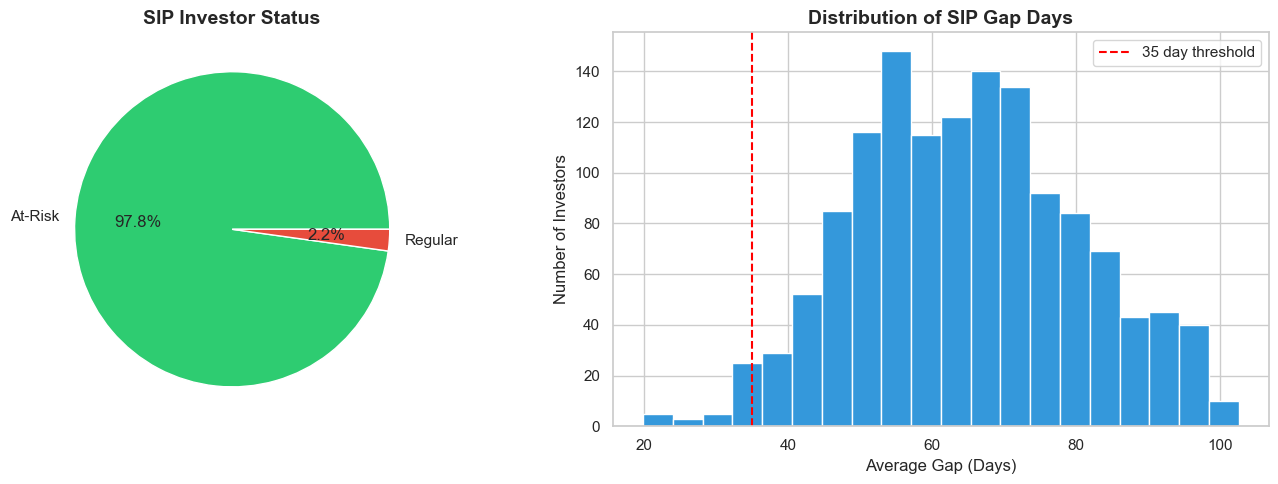


✅ Saved: sip_continuity.csv + chart


In [5]:
# =====================
# TASK 4 - SIP CONTINUATION ANALYSIS
# =====================

print("=" * 60)
print("TASK 4 - SIP CONTINUATION ANALYSIS")
print("=" * 60)

# Sirf SIP transactions
sip_only = txn_df[
    txn_df['transaction_type'] == 'SIP'
].sort_values(['investor_id', 'transaction_date'])

# 6+ SIP karne wale investors
sip_counts = sip_only.groupby(
    'investor_id')['transaction_date'].count()
active_investors = sip_counts[sip_counts >= 6].index

sip_active = sip_only[
    sip_only['investor_id'].isin(active_investors)]

# Average gap calculate karo
def avg_gap(dates):
    dates = sorted(dates)
    if len(dates) < 2:
        return None
    gaps = [(dates[i+1] - dates[i]).days
            for i in range(len(dates)-1)]
    return round(np.mean(gaps), 1)

gap_df = sip_active.groupby('investor_id')[
    'transaction_date'].apply(
    lambda x: avg_gap(list(x))).reset_index()
gap_df.columns = ['investor_id', 'avg_gap_days']
gap_df = gap_df.dropna()

# At-risk flag karo — gap > 35 days
gap_df['status'] = gap_df['avg_gap_days'].apply(
    lambda x: 'At-Risk' if x > 35 else 'Regular')

print(f"\nTotal investors with 6+ SIPs: {len(gap_df)}")
print(f"Regular investors (≤35 days): "
      f"{len(gap_df[gap_df['status']=='Regular'])}")
print(f"At-Risk investors (>35 days): "
      f"{len(gap_df[gap_df['status']=='At-Risk'])}")
print(f"\nAverage gap distribution:")
print(gap_df['avg_gap_days'].describe().round(2))

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gap_df['status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    ax=axes[0])
axes[0].set_title('SIP Investor Status',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

axes[1].hist(gap_df['avg_gap_days'],
             bins=20, color='#3498db',
             edgecolor='white')
axes[1].axvline(x=35, color='red',
                linestyle='--', label='35 day threshold')
axes[1].set_title('Distribution of SIP Gap Days',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Gap (Days)')
axes[1].set_ylabel('Number of Investors')
axes[1].legend()

plt.tight_layout()
plt.savefig('../charts/16_sip_continuity.png', dpi=150)
plt.show()

gap_df.to_csv(
    "../data/processed/sip_continuity.csv", index=False)
print("\n✅ Saved: sip_continuity.csv + chart")

In [6]:
# =====================
# TASK 5 - FUND RECOMMENDER
# =====================

print("=" * 60)
print("TASK 5 - FUND RECOMMENDATION SYSTEM")
print("=" * 60)

def recommend_funds(risk_appetite, top_n=3):
    """
    Input: risk_appetite = 'Low' / 'Moderate' / 'High'
    Output: Top N funds by Sharpe ratio
    """
    # Risk mapping
    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }

    valid_grades = risk_map.get(risk_appetite, ['Moderate'])

    # Filter funds by risk grade
    filtered = perf_df[
        perf_df['risk_grade'].isin(valid_grades)
    ].copy()

    if len(filtered) == 0:
        print(f"No funds found for {risk_appetite} risk!")
        return None

    # Top N by Sharpe Ratio
    top_funds = filtered.nlargest(top_n, 'sharpe_ratio')[
        ['scheme_name', 'fund_house', 'risk_grade',
         'sharpe_ratio', 'return_3yr_pct',
         'expense_ratio_pct']
    ].reset_index(drop=True)
    top_funds.index += 1

    return top_funds

# Test karo teen risk appetites ke liye
for risk in ['Low', 'Moderate', 'High']:
    print(f"\n{'='*50}")
    print(f"🎯 Recommended Funds for {risk} Risk Investor:")
    print(f"{'='*50}")
    result = recommend_funds(risk)
    if result is not None:
        print(result.to_string())

print("\n✅ Recommender system working!")

TASK 5 - FUND RECOMMENDATION SYSTEM

🎯 Recommended Funds for Low Risk Investor:
                                scheme_name                fund_house risk_grade  sharpe_ratio  return_3yr_pct  expense_ratio_pct
1  ICICI Pru Liquid Fund - Regular - Growth       ICICI Prudential MF        Low          7.68            7.68               0.74
2      Kotak Liquid Fund - Regular - Growth         Kotak Mahindra MF        Low          6.18            6.18               0.60
3       ABSL Liquid Fund - Regular - Growth  Aditya Birla Sun Life MF        Low          5.14            5.14               0.79

🎯 Recommended Funds for Moderate Risk Investor:
                                     scheme_name           fund_house risk_grade  sharpe_ratio  return_3yr_pct  expense_ratio_pct
1      HDFC Top 100 Fund - Regular Plan - Growth     HDFC Mutual Fund   Moderate          1.06           14.84               1.55
2  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF   Moderate          1

TASK 6 - SECTOR CONCENTRATION (HHI)

Sector Concentration by Fund:
                                          scheme_name  hhi_score  num_sectors     top_sector concentration
                Axis Bluechip Fund - Regular - Growth    2968.28            7             IT          High
        Mirae Asset Tax Saver Fund - Regular - Growth    2550.94            7        Banking          High
    HDFC Mid-Cap Opportunities Fund - Direct - Growth    2531.55            6        Banking          High
                UTI Flexi Cap Fund - Regular - Growth    2513.32            6         Pharma          High
                   DSP Midcap Fund - Regular - Growth    2410.77            7         Pharma      Moderate
             ICICI Pru Midcap Fund - Regular - Growth    2386.00            7         Pharma      Moderate
                       Nippon India ETF Nifty 50 BeES    2375.44            6             IT      Moderate
            SBI Small Cap Fund - Direct Plan - Growth    2323.61            7

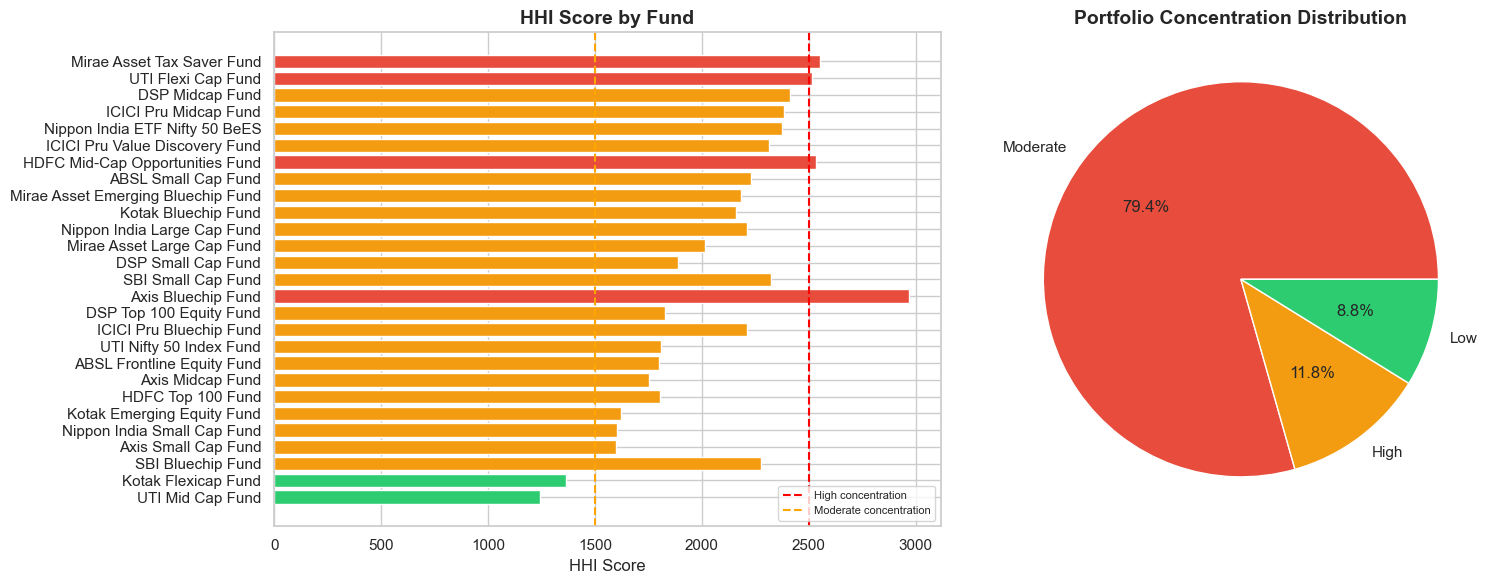


✅ Saved: sector_hhi.csv + chart


In [7]:
# =====================
# TASK 6 - SECTOR HHI ANALYSIS
# =====================

print("=" * 60)
print("TASK 6 - SECTOR CONCENTRATION (HHI)")
print("=" * 60)

# Equity funds only
equity_funds = fund_df[
    fund_df['category'] == 'Equity']['amfi_code'].tolist()
equity_holdings = holdings_df[
    holdings_df['amfi_code'].isin(equity_funds)]

# HHI calculate karo per fund
hhi_results = []

for code, group in equity_holdings.groupby('amfi_code'):
    # Sector weights normalize karo
    sector_weights = group.groupby(
        'sector')['weight_pct'].sum()
    total_weight = sector_weights.sum()

    if total_weight == 0:
        continue

    normalized = sector_weights / total_weight * 100

    # HHI = sum of squared weights
    hhi = round((normalized ** 2).sum(), 2)

    hhi_results.append({
        'amfi_code': code,
        'hhi_score': hhi,
        'num_sectors': len(sector_weights),
        'top_sector': sector_weights.idxmax(),
        'top_sector_weight': round(
            sector_weights.max(), 2)
    })

hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.merge(
    fund_df[['amfi_code', 'scheme_name',
             'sub_category']],
    on='amfi_code', how='left')

# Concentration level
hhi_df['concentration'] = hhi_df['hhi_score'].apply(
    lambda x: 'High' if x > 2500
    else ('Moderate' if x > 1500 else 'Low'))

print("\nSector Concentration by Fund:")
print(hhi_df[['scheme_name', 'hhi_score',
              'num_sectors', 'top_sector',
              'concentration']].sort_values(
    'hhi_score', ascending=False).to_string(index=False))

# Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# HHI bar chart
hhi_sorted = hhi_df.sort_values(
    'hhi_score', ascending=True)
colors = ['#e74c3c' if x == 'High'
          else '#f39c12' if x == 'Moderate'
          else '#2ecc71'
          for x in hhi_sorted['concentration']]
axes[0].barh(
    hhi_sorted['scheme_name'].str.replace(
        ' - Direct Plan - Growth', '').str.replace(
        ' - Direct - Growth', '').str.replace(
        ' - Regular Plan - Growth', '').str.replace(
        ' - Regular - Growth', ''),
    hhi_sorted['hhi_score'],
    color=colors)
axes[0].axvline(x=2500, color='red',
                linestyle='--', label='High concentration')
axes[0].axvline(x=1500, color='orange',
                linestyle='--', label='Moderate concentration')
axes[0].set_title('HHI Score by Fund',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('HHI Score')
axes[0].legend(fontsize=8)

# Concentration distribution pie
hhi_df['concentration'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#e74c3c', '#f39c12', '#2ecc71'],
    ax=axes[1])
axes[1].set_title('Portfolio Concentration Distribution',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../charts/17_sector_hhi.png', dpi=150)
plt.show()

hhi_df.to_csv(
    "../data/processed/sector_hhi.csv", index=False)
print("\n✅ Saved: sector_hhi.csv + chart")